In [1]:
import pandas as pd

df = pd.read_csv('../data/dataset.csv')
print(df.shape)
print(df.head())

(114000, 21)
   Unnamed: 0                track_id                 artists  \
0           0  5SuOikwiRyPMVoIQDJUgSV             Gen Hoshino   
1           1  4qPNDBW1i3p13qLCt0Ki3A            Ben Woodward   
2           2  1iJBSr7s7jYXzM8EGcbK5b  Ingrid Michaelson;ZAYN   
3           3  6lfxq3CG4xtTiEg7opyCyx            Kina Grannis   
4           4  5vjLSffimiIP26QG5WcN2K        Chord Overstreet   

                                          album_name  \
0                                             Comedy   
1                                   Ghost (Acoustic)   
2                                     To Begin Again   
3  Crazy Rich Asians (Original Motion Picture Sou...   
4                                            Hold On   

                   track_name  popularity  duration_ms  explicit  \
0                      Comedy          73       230666     False   
1            Ghost - Acoustic          55       149610     False   
2              To Begin Again          57       210826 

In [2]:
print(df.columns.tolist())
print(df.dtypes)

['Unnamed: 0', 'track_id', 'artists', 'album_name', 'track_name', 'popularity', 'duration_ms', 'explicit', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature', 'track_genre']
Unnamed: 0            int64
track_id             object
artists              object
album_name           object
track_name           object
popularity            int64
duration_ms           int64
explicit               bool
danceability        float64
energy              float64
key                   int64
loudness            float64
mode                  int64
speechiness         float64
acousticness        float64
instrumentalness    float64
liveness            float64
valence             float64
tempo               float64
time_signature        int64
track_genre          object
dtype: object


In [3]:
# Verificar valores nulos e duplicatas
print("Valores nulos por coluna:")
print(df.isnull().sum())
print(f"\nLinhas duplicadas: {df.duplicated().sum()}")

Valores nulos por coluna:
Unnamed: 0          0
track_id            0
artists             1
album_name          1
track_name          1
popularity          0
duration_ms         0
explicit            0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
time_signature      0
track_genre         0
dtype: int64

Linhas duplicadas: 0


In [4]:
# Remover linhas com valores nulos e coluna desnecessária
df = df.drop(columns=['Unnamed: 0'])
df = df.dropna()

print(f"Dataset final: {df.shape}")

Dataset final: (113999, 20)


C:\Users\isagu\AppData\Local\Temp\ipykernel_20080\4233900668.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_generos.values, y=top_generos.index, palette="viridis")


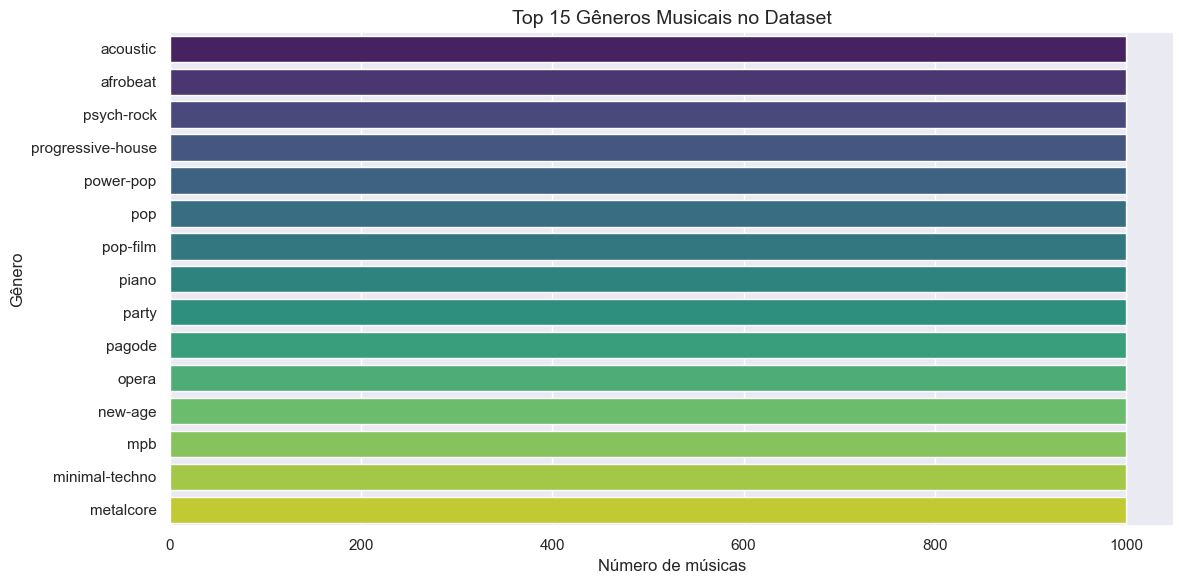

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# Estilo dos gráficos
sns.set_theme(style="darkgrid")

# Quais gêneros aparecem mais no dataset?
top_generos = df['track_genre'].value_counts().head(15)

plt.figure(figsize=(12, 6))
sns.barplot(x=top_generos.values, y=top_generos.index, palette="viridis")
plt.title("Top 15 Gêneros Musicais no Dataset", fontsize=14)
plt.xlabel("Número de músicas")
plt.ylabel("Gênero")
plt.tight_layout()
plt.show()

C:\Users\isagu\AppData\Local\Temp\ipykernel_20080\3878746088.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=popularidade_genero.values, y=popularidade_genero.index, palette="magma")


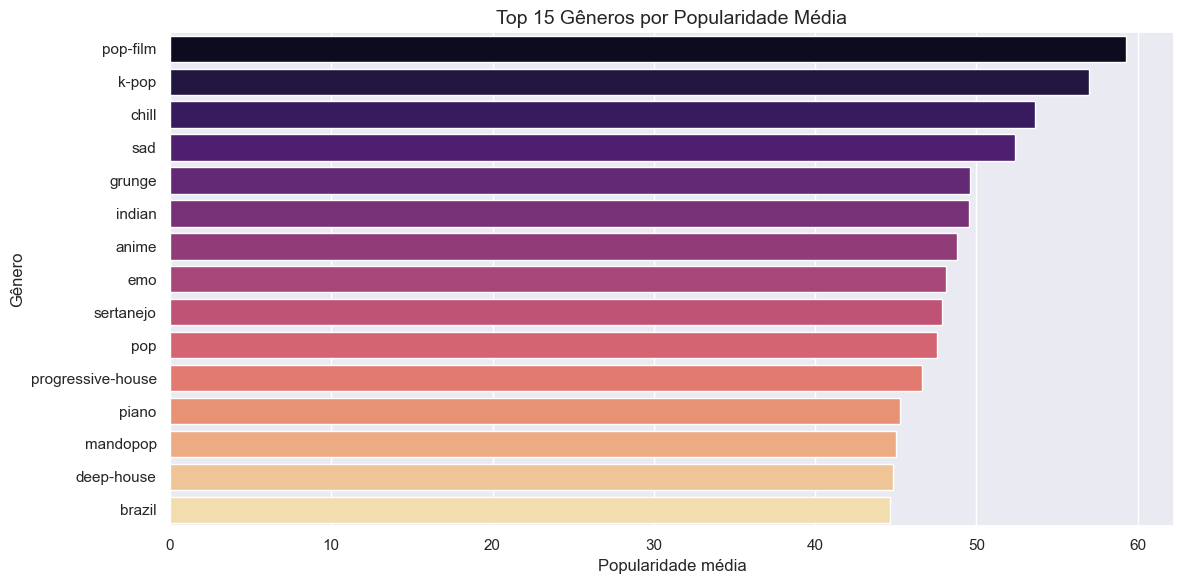

In [8]:
# Quais gêneros têm as músicas mais populares em média?
popularidade_genero = df.groupby('track_genre')['popularity'].mean().sort_values(ascending=False).head(15)

plt.figure(figsize=(12, 6))
sns.barplot(x=popularidade_genero.values, y=popularidade_genero.index, palette="magma")
plt.title("Top 15 Gêneros por Popularidade Média", fontsize=14)
plt.xlabel("Popularidade média")
plt.ylabel("Gênero")
plt.tight_layout()
plt.show()

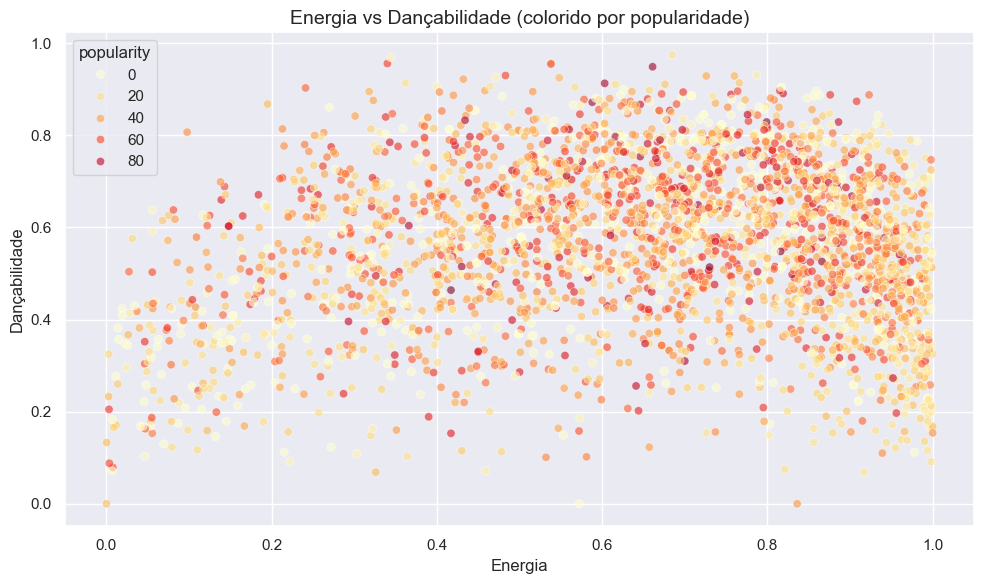

In [10]:
# Como energia e dançabilidade se relacionam com popularidade?
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df.sample(3000, random_state=42),
    x='energy',
    y='danceability',
    hue='popularity',
    palette='YlOrRd',
    alpha=0.6
)
plt.title("Energia vs Dançabilidade (colorido por popularidade)", fontsize=14)
plt.xlabel("Energia")
plt.ylabel("Dançabilidade")
plt.tight_layout()
plt.show()

C:\Users\isagu\AppData\Local\Temp\ipykernel_20080\2331495573.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=valencia_genero.head(10).values,
C:\Users\isagu\AppData\Local\Temp\ipykernel_20080\2331495573.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=valencia_genero.tail(10).values,


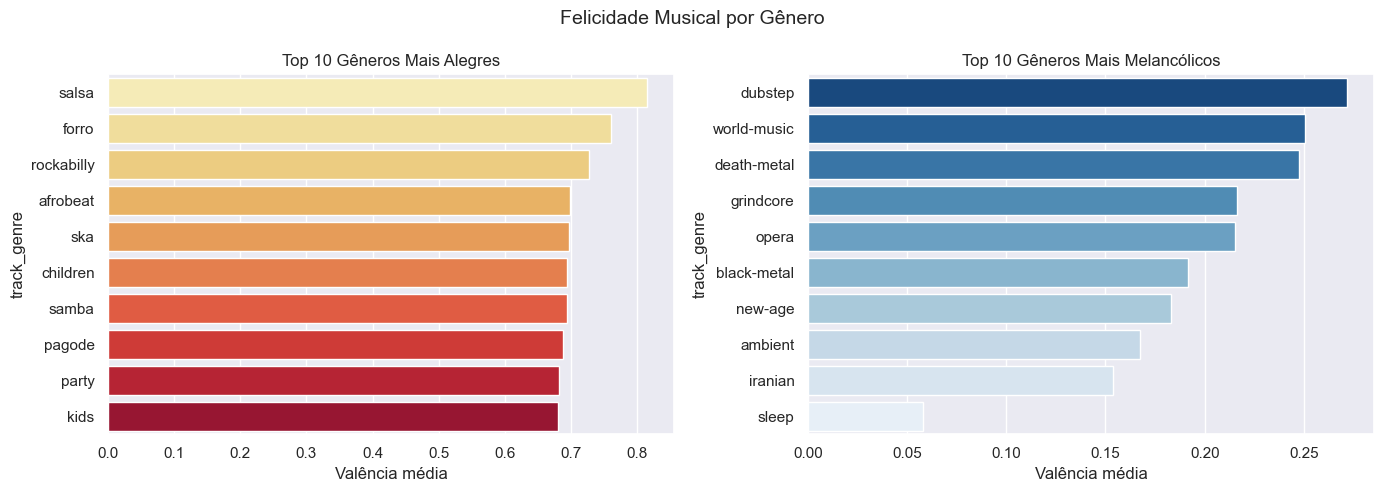

In [11]:
# Valência média por gênero - quais gêneros são mais "felizes"?
valencia_genero = df.groupby('track_genre')['valence'].mean().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Top 10 mais felizes
sns.barplot(x=valencia_genero.head(10).values, 
            y=valencia_genero.head(10).index, 
            palette='YlOrRd', ax=axes[0])
axes[0].set_title("Top 10 Gêneros Mais Alegres")
axes[0].set_xlabel("Valência média")

# Top 10 mais tristes
sns.barplot(x=valencia_genero.tail(10).values, 
            y=valencia_genero.tail(10).index, 
            palette='Blues_r', ax=axes[1])
axes[1].set_title("Top 10 Gêneros Mais Melancólicos")
axes[1].set_xlabel("Valência média")

plt.suptitle("Felicidade Musical por Gênero", fontsize=14)
plt.tight_layout()
plt.show()

C:\Users\isagu\AppData\Local\Temp\ipykernel_20080\1699769828.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=pop_br.values, y=pop_br.index, palette='YlOrRd', ax=axes[0])
C:\Users\isagu\AppData\Local\Temp\ipykernel_20080\1699769828.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=danc_br.values, y=danc_br.index, palette='YlOrRd', ax=axes[1])
C:\Users\isagu\AppData\Local\Temp\ipykernel_20080\1699769828.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=val_br.values, y=val_br.index, palette='YlOrRd', ax=axes[2])


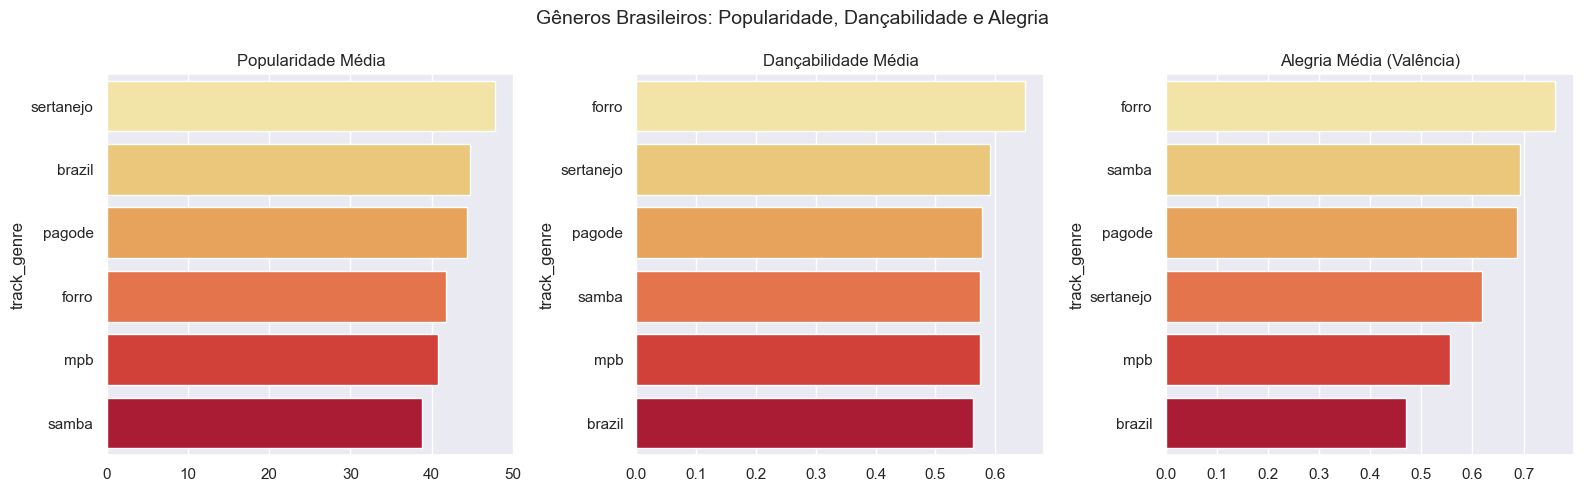

In [14]:
# Gêneros brasileiros comparados entre si
generos_br = ['brazil', 'mpb', 'pagode', 'samba', 'forro', 'sertanejo', 'axe', 'bossanova']
df_br = df[df['track_genre'].isin(generos_br)]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Popularidade
pop_br = df_br.groupby('track_genre')['popularity'].mean().sort_values(ascending=False)
sns.barplot(x=pop_br.values, y=pop_br.index, palette='YlOrRd', ax=axes[0])
axes[0].set_title("Popularidade Média")
axes[0].set_xlabel("")

# Dançabilidade
danc_br = df_br.groupby('track_genre')['danceability'].mean().sort_values(ascending=False)
sns.barplot(x=danc_br.values, y=danc_br.index, palette='YlOrRd', ax=axes[1])
axes[1].set_title("Dançabilidade Média")
axes[1].set_xlabel("")

# Valência (alegria)
val_br = df_br.groupby('track_genre')['valence'].mean().sort_values(ascending=False)
sns.barplot(x=val_br.values, y=val_br.index, palette='YlOrRd', ax=axes[2])
axes[2].set_title("Alegria Média (Valência)")
axes[2].set_xlabel("")

plt.suptitle("Gêneros Brasileiros: Popularidade, Dançabilidade e Alegria", fontsize=14)
plt.tight_layout()
plt.show()